Car Price Prediction using Machine Learning

This project demonstrates the use of machine learning techniques to predict car prices. It includes data preprocessing, model training, prediction, and evaluation to understand how regression models can be applied to real-world prediction problems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot
import seaborn as sns
dataset=pd.read_csv("car data.csv")
dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Dataset understanding

The dataset contains information about cars such as car name, year, fuel type, presnt price, transmission type, kilometers driven, and selling price. The target variable for prediction is the Selling_Price column.

In [2]:
print(dataset.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
dataset.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
dataset=dataset.drop(['Car_Name'],axis=1)

In [6]:
dataset.isnull().sum()

Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
dataset=pd.get_dummies(dataset,drop_first=True)

Categorical columns such as Fuel_Type, Selling_type, and Transmission were converted into numerical format using one-hot encoding. This preprocessing step is necessary because machine learning models cannot process text data directly.

In [8]:
x=dataset.drop('Selling_Price',axis=1)
y=dataset['Selling_Price']

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

The dataset was divided into training and testing sets. The training data is used for learning patterns, while the testing data is used to evaluate model performance on unseen data.

In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print("Model trained successfully")

Model trained successfully


A Linear Regression model was trained using the processed dataset. The model learns the relationship between car features and selling price.

In [11]:
y_pred=model.predict(X_test)
print(y_pred[:5])

[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657]


The trained model successfully predicted car selling prices for the test dataset based on the given features.

In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

MAE: 1.216374019332988
MSE: 3.481349830510787


The model evaluation metrics indicate how closely the predicted prices match the actual prices. Lower error values suggest better prediction performance.

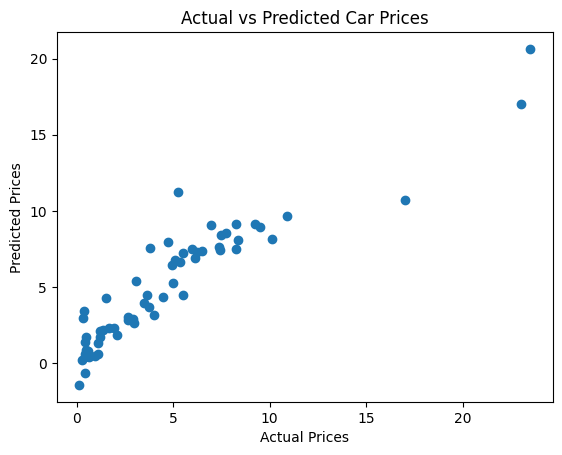

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

The scatter plot shows a positive relationship between actual and predicted car prices. Most predicted values are reasonably close to the actual prices, indicating that the regression model performs effectively on the dataset.

Conclusion

This project demonstrates the use of Linear Regression for predicting car prices based on multiple car-related features. Data preprocessing and model evaluation were important steps in building an effective prediction model.